<a href="https://colab.research.google.com/github/nasro10z/euro-exchange-rate-analysis/blob/main/Euro_exchange_rate_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Euro Exchange Rate Analysis (1999 - Present)

This project explores the historical volatility and trends of the Euro against various global currencies. By analyzing over 20 years of daily exchange rate data, we visualize how major geopolitical events like the 2008 Financial Crisis, Brexit, and the COVID-19 pandemic shaped the global economy.

Loading the dataset and seeing a preview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


euro_rate_df = pd.read_csv('/content/drive/MyDrive/euro-daily-hist_1999_2022.csv')
euro_rate_df.head()

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
0,2025-04-02,1.7146,1.9558,6.1212,1.5479,0.9543,7.8529,NaN,24.963,7.4611,...,4.9775,NaN,10.764,1.4508,NaN,NaN,36.93,40.9573,1.0803,20.1042
1,2025-04-01,1.7255,1.9558,6.1679,1.5529,0.952,7.8431,NaN,24.954,7.4616,...,4.9774,NaN,10.816,1.4492,NaN,NaN,36.846,40.9201,1.0788,19.7741
2,2025-03-31,1.7318,1.9558,6.2507,1.5533,0.9531,7.8442,NaN,24.962,7.4613,...,4.9771,NaN,10.849,1.4519,NaN,NaN,36.706,41.0399,1.0815,19.8782
3,2025-03-28,1.712,1.9558,6.2252,1.5444,0.9525,7.8445,NaN,24.96,7.4616,...,4.9774,NaN,10.82,1.4481,NaN,NaN,36.664,41.0387,1.0797,19.6113
4,2025-03-27,1.7101,1.9558,6.2154,1.5425,0.9524,7.8361,NaN,24.982,7.4605,...,4.9773,NaN,10.8235,1.445,NaN,NaN,36.529,40.9940,1.0785,19.7061


**Initial Data Loading:** We begin by importing essential libraries and loading the raw dataset. The initial preview shows currency columns formatted as strings with brackets, which will require cleaning.

data set shape

In [ ]:
euro_rate_df.shape

(6785, 41)

exploring dataset infos non null count for each currency and data types

In [ ]:
euro_rate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6785 entries, 0 to 6784
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              6785 non-null   object 
 1   [Australian dollar ]      6785 non-null   object 
 2   [Bulgarian lev ]          6383 non-null   object 
 3   [Brazilian real ]         6517 non-null   object 
 4   [Canadian dollar ]        6785 non-null   object 
 5   [Swiss franc ]            6785 non-null   object 
 6   [Chinese yuan renminbi ]  6517 non-null   object 
 7   [Cypriot pound ]          2346 non-null   object 
 8   [Czech koruna ]           6785 non-null   object 
 9   [Danish krone ]           6785 non-null   object 
 10  [Estonian kroon ]         3130 non-null   object 
 11  [UK pound sterling ]      6785 non-null   object 
 12  [Greek drachma ]          520 non-null    object 
 13  [Hong Kong dollar ]       6785 non-null   object 
 14  [Croatia

**Data Inspection:** The `.info()` method reveals that most columns are stored as objects (strings) and contain varying levels of missing data. We need to convert these to numeric formats for analysis.

only iceland krona , Romanian leu, Turkish lira have float data type

detecting currencies with incomplete day to day exchange rate

In [ ]:
from numpy._core.fromnumeric import shape
not_completed_currencies = []
for currency in euro_rate_df.columns:
  if (euro_rate_df[currency].isnull().sum() > 0):
    not_completed_currencies.append(currency)
print(not_completed_currencies)


['[Bulgarian lev ]', '[Brazilian real ]', '[Chinese yuan renminbi ]', '[Cypriot pound ]', '[Estonian kroon ]', '[Greek drachma ]', '[Croatian kuna ]', '[Israeli shekel ]', '[Indian rupee ]', '[Iceland krona ]', '[Lithuanian litas ]', '[Latvian lats ]', '[Maltese lira ]', '[Romanian leu ]', '[Russian rouble ]', '[Slovenian tolar ]', '[Slovak koruna ]', '[Turkish lira ]']


# Converting currencies dtype to float

In [ ]:
# Look at rows where the original data wasn't a number
# (Replace 'USD' with any currency that saw a drop)
euro_df = euro_rate_df.drop(columns=['Period\\Unit:'])
# 1. Create a boolean mask of where the numeric conversion fails
# This returns True for things like '-', '?', or text, and False for valid numbers
invalid_mask = euro_df.apply(pd.to_numeric, errors='coerce').isna() & euro_df.notna()

# 2. Use that mask to extract the original weird text values across all columns
# .values.flatten() turns the 2D dataframe grid into one long list of elements
all_weird_values = euro_df[invalid_mask].values.flatten()

# 3. Filter out the actual Python NaNs from our list, leaving only the original strings
unique_non_numeric = pd.Series(all_weird_values).dropna().unique()

print("--- Unique characters causing drops across ALL columns ---")
print(unique_non_numeric)

--- Unique characters causing drops across ALL columns ---
['-']


**Anomaly Detection:** Before conversion, we identify characters that prevent numeric parsing. The dash (`-`) is identified as a placeholder for missing values in this dataset.

In [ ]:
def clean_currency_rates(df, columns_to_convert=None):
    """
    Converts currency exchange rate columns from object/string to float.
    Automatically turns text markers like '-' into NaN values.

    Parameters:
    df (DataFrame): The original exchange rate DataFrame.
    columns_to_convert (list): List of columns to convert. If None, converts all columns.

    Returns:
    DataFrame: A copy of the DataFrame with converted float columns.
    """
    # Create a copy to avoid modifying the original data
    df_cleaned = df.copy()

    # If no columns specified, use all columns
    if columns_to_convert is None:
        columns_to_convert = df_cleaned.columns

    # Apply the numeric conversion column by column
    for col in columns_to_convert:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

    return df_cleaned

In [ ]:
# Grab all column names except the date column
currency_cols = [col for col in euro_rate_df.columns if col != r'Period\Unit:']

# Run the function only on those currencies
euro_rate_df = clean_currency_rates(euro_rate_df, columns_to_convert=currency_cols)

**Data Cleaning:** Using a custom function, we convert all currency columns to floats. This process automatically handles the non-numeric markers by turning them into `NaN` (Not a Number) values.

In [ ]:
euro_rate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6785 entries, 0 to 6784
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              6785 non-null   object 
 1   [Australian dollar ]      6723 non-null   float64
 2   [Bulgarian lev ]          6325 non-null   float64
 3   [Brazilian real ]         6456 non-null   float64
 4   [Canadian dollar ]        6723 non-null   float64
 5   [Swiss franc ]            6723 non-null   float64
 6   [Chinese yuan renminbi ]  6456 non-null   float64
 7   [Cypriot pound ]          2304 non-null   float64
 8   [Czech koruna ]           6723 non-null   float64
 9   [Danish krone ]           6723 non-null   float64
 10  [Estonian kroon ]         3074 non-null   float64
 11  [UK pound sterling ]      6723 non-null   float64
 12  [Greek drachma ]          514 non-null    float64
 13  [Hong Kong dollar ]       6723 non-null   float64
 14  [Croatia

In [ ]:
currency_lifespans = {
    '[Bulgarian lev ]': {'start': '1999-01-04', 'end': '2025-12-31'},       # Adopted Euro Jan 1, 2026
    '[Brazilian real ]': {'start': '2000-01-03', 'end': None},              # Actively traded
    '[Chinese yuan renminbi ]': {'start': '2000-01-03', 'end': None},       # Actively traded
    '[Cypriot pound ]': {'start': '1999-01-04', 'end': '2007-12-31'},       # Adopted Euro Jan 1, 2008
    '[Estonian kroon ]': {'start': '1999-01-04', 'end': '2010-12-31'},      # Adopted Euro Jan 1, 2011
    '[Greek drachma ]': {'start': '1999-01-04', 'end': '2000-12-29'},       # Adopted Euro Jan 1, 2001
    '[Croatian kuna ]': {'start': '2005-05-02', 'end': '2022-12-30'},       # Adopted Euro Jan 1, 2023
    '[Israeli shekel ]': {'start': '2000-01-03', 'end': None},              # Actively traded
    '[Indian rupee ]': {'start': '2000-01-03', 'end': None},                # Actively traded
    '[Iceland krona ]': {'start': '1999-01-04', 'end': None},               # Actively traded
    '[Lithuanian litas ]': {'start': '1999-01-04', 'end': '2014-12-31'},    # Adopted Euro Jan 1, 2015
    '[Latvian lats ]': {'start': '1999-01-04', 'end': '2013-12-31'},        # Adopted Euro Jan 1, 2014
    '[Maltese lira ]': {'start': '1999-01-04', 'end': '2007-12-31'},        # Adopted Euro Jan 1, 2008
    '[Romanian leu ]': {'start': '1999-01-04', 'end': None},                # Actively traded (ROL became RON in 2005)
    '[Russian rouble ]': {'start': '2000-01-03', 'end': '2022-03-01'},      # ECB suspended trading on March 1, 2022
    '[Slovenian tolar ]': {'start': '1999-01-04', 'end': '2006-12-29'},      # Adopted Euro Jan 1, 2007
    '[Slovak koruna ]': {'start': '1999-01-04', 'end': '2008-12-31'},       # Adopted Euro Jan 1, 2009
    '[Turkish lira ]': {'start': '1999-01-04', 'end': None}                 # Actively traded
}

Fixing missing data by forward filling week end dates and respecting currencies lifespans

parsing Period\Unit: column to date type

In [ ]:
euro_rate_df = euro_rate_df.rename(columns={'Period\\Unit:': 'Date'})
euro_rate_df['Date'] = pd.to_datetime(euro_rate_df['Date'])
euro_rate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6785 entries, 0 to 6784
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      6785 non-null   datetime64[ns]
 1   [Australian dollar ]      6723 non-null   float64       
 2   [Bulgarian lev ]          6325 non-null   float64       
 3   [Brazilian real ]         6456 non-null   float64       
 4   [Canadian dollar ]        6723 non-null   float64       
 5   [Swiss franc ]            6723 non-null   float64       
 6   [Chinese yuan renminbi ]  6456 non-null   float64       
 7   [Cypriot pound ]          2304 non-null   float64       
 8   [Czech koruna ]           6723 non-null   float64       
 9   [Danish krone ]           6723 non-null   float64       
 10  [Estonian kroon ]         3074 non-null   float64       
 11  [UK pound sterling ]      6723 non-null   float64       
 12  [Greek drachma ]    

In [ ]:
for col in currency_cols:
  euro_rate_df[col] = euro_rate_df[col].fillna(method='ffill')
  print("forward fill completed ")
euro_rate_df.info()


forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
forward fill completed 
<class 'pandas.core.frame.DataFrame'>
Ra

/tmp/ipykernel_2733/1929437837.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  euro_rate_df[col] = euro_rate_df[col].fillna(method='ffill')


**Handling Missing Values:** To ensure continuous time-series plots, we apply a forward-fill method. This carries the last known exchange rate into weekends and holidays where trading was closed.

<Axes: xlabel='Date'>

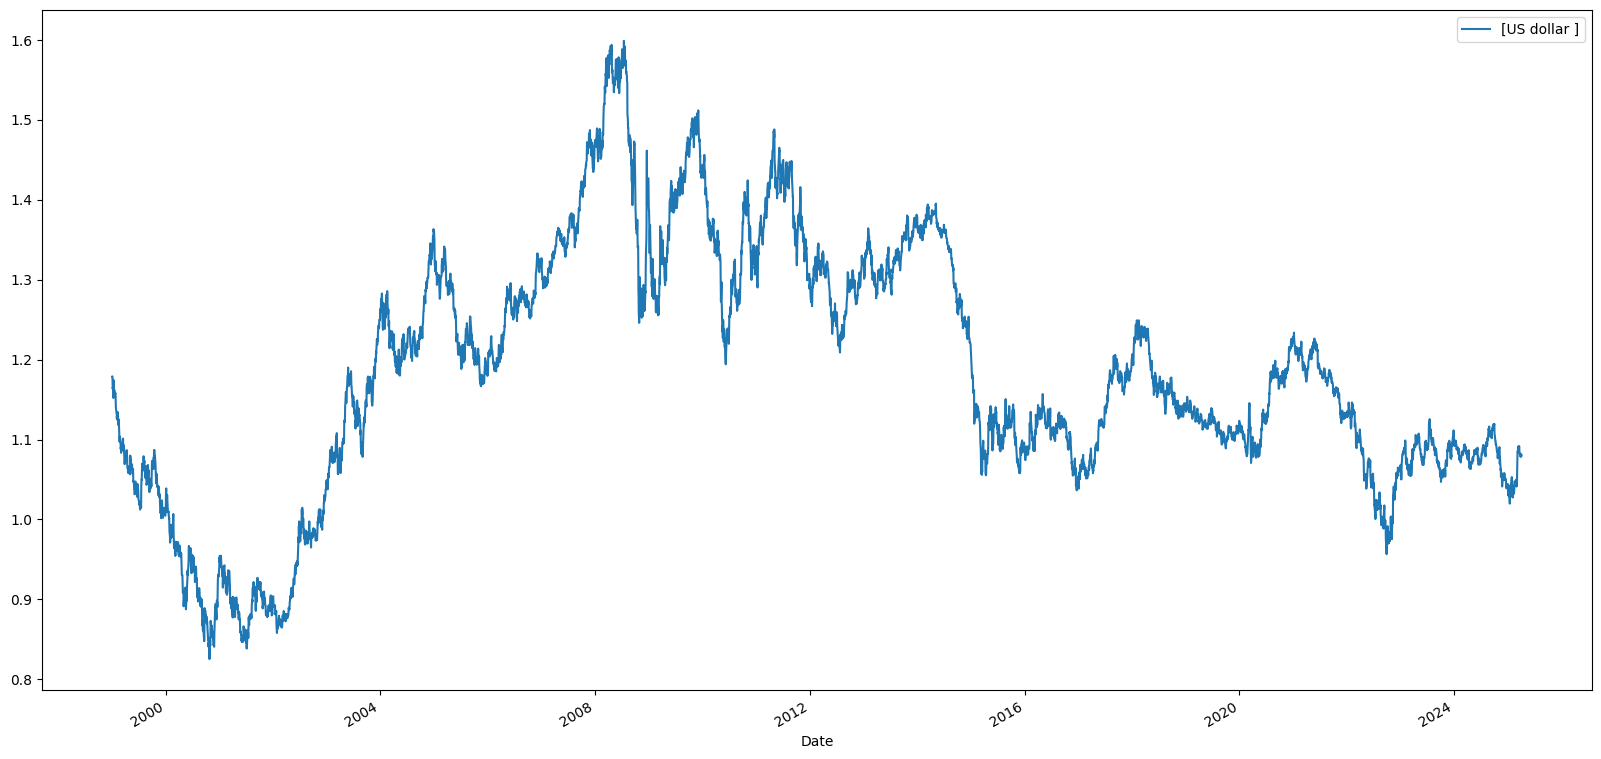

In [ ]:
# plot euro/usd
euro_rate_df.plot(x='Date', y='[US dollar ]',figsize=(20,10))

### EUR/USD Fluctuations (1999-2022)
We will use a 30-day rolling mean to visualize the long-term trend more clearly and annotate key historical events.

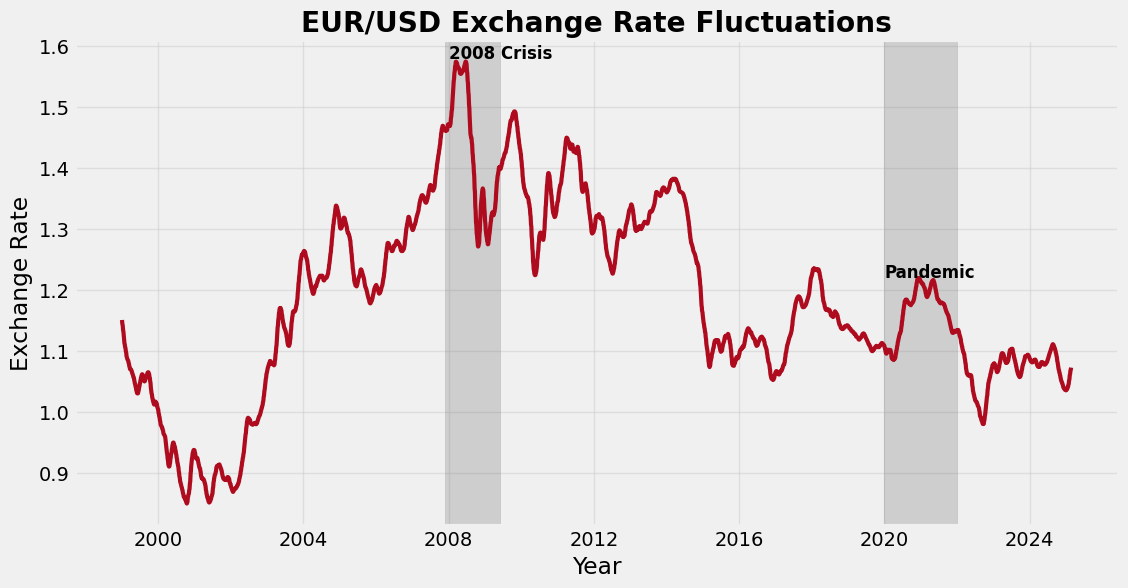

In [ ]:
import matplotlib.style as style
style.use('fivethirtyeight')

# Calculate rolling mean for smoother trend
euro_rate_df['rolling_mean'] = euro_rate_df['[US dollar ]'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(euro_rate_df['Date'], euro_rate_df['rolling_mean'], linewidth=3, color='#af0b1e')

# Highlighting key inflection points
ax.axvspan(pd.to_datetime('2007-12-01'), pd.to_datetime('2009-06-01'), alpha=0.3, color='grey')
ax.text(pd.to_datetime('2008-01-01'), 1.58, '2008 Crisis', size=12, weight='bold')

ax.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2021-12-31'), alpha=0.3, color='grey')
ax.text(pd.to_datetime('2020-01-01'), 1.22, 'Pandemic', size=12, weight='bold')

ax.set_title('EUR/USD Exchange Rate Fluctuations', weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Exchange Rate')
plt.grid(alpha=0.5)
plt.show()

**USD Trend Analysis:** The plot above uses a 30-day rolling mean to smooth out daily volatility, highlighting the long-term impact of the 2008 crash and the pandemic on the EUR/USD pair.

In [ ]:
target_date = '2016-06-23'
row_filter = euro_rate_df['Date'] == target_date
euro_rate_df.loc[row_filter, '[UK pound sterling ]'].values[0]

np.float64(0.76595)

### EUR/GBP Fluctuations (1999-2022)
Similar to the USD analysis, we use a rolling mean to observe the impact of key UK and European economic events on the Sterling pound.

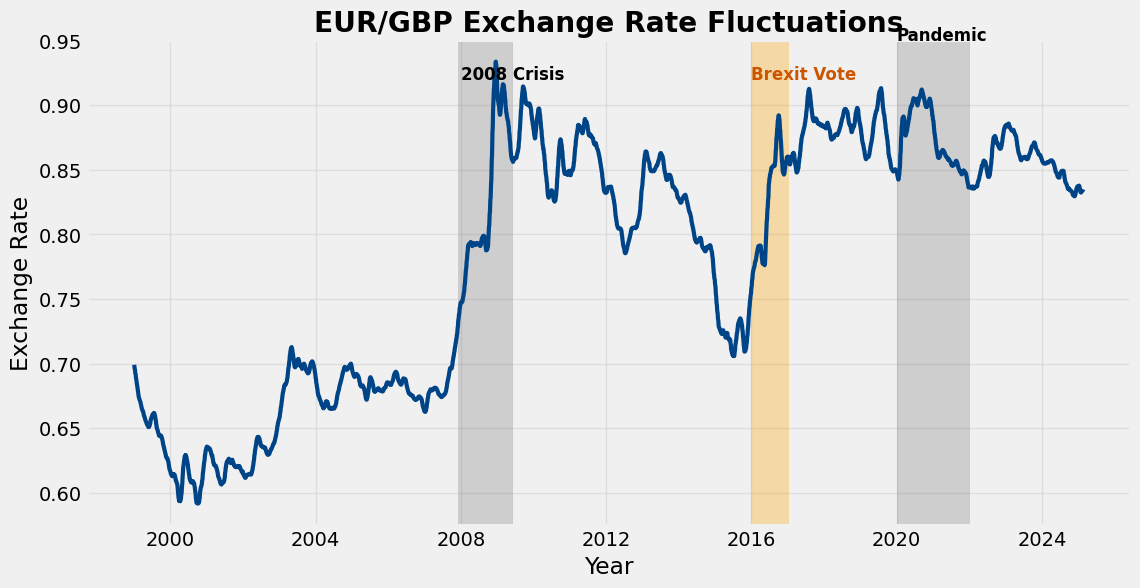

In [ ]:
import matplotlib.style as style
style.use('fivethirtyeight')

# Calculate rolling mean for GBP
euro_rate_df['rolling_mean_GBP'] = euro_rate_df['[UK pound sterling ]'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(euro_rate_df['Date'], euro_rate_df['rolling_mean_GBP'], linewidth=3, color='#004488')

# Highlighting key inflection points
# 2008 Financial Crisis
ax.axvspan(pd.to_datetime('2007-12-01'), pd.to_datetime('2009-06-01'), alpha=0.3, color='grey')
ax.text(pd.to_datetime('2008-01-01'), 0.92, '2008 Crisis', size=12, weight='bold')

# Brexit Referendum (June 2016)
ax.axvspan(pd.to_datetime('2016-01-01'), pd.to_datetime('2017-01-01'), alpha=0.3, color='orange')
ax.text(pd.to_datetime('2016-01-01'), 0.92, 'Brexit Vote', size=12, weight='bold', color='#cc5500')

# Pandemic
ax.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2021-12-31'), alpha=0.3, color='grey')
ax.text(pd.to_datetime('2020-01-01'), 0.95, 'Pandemic', size=12, weight='bold')

ax.set_title('EUR/GBP Exchange Rate Fluctuations', weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Exchange Rate')
plt.grid(alpha=0.5)
plt.show()

### Comparaison directe : GBP vs CHF (Même axe Y)
En affichant les deux devises sur le même axe, on peut observer non seulement leurs tendances respectives, mais aussi l'écart absolu entre leurs taux de change face à l'Euro.

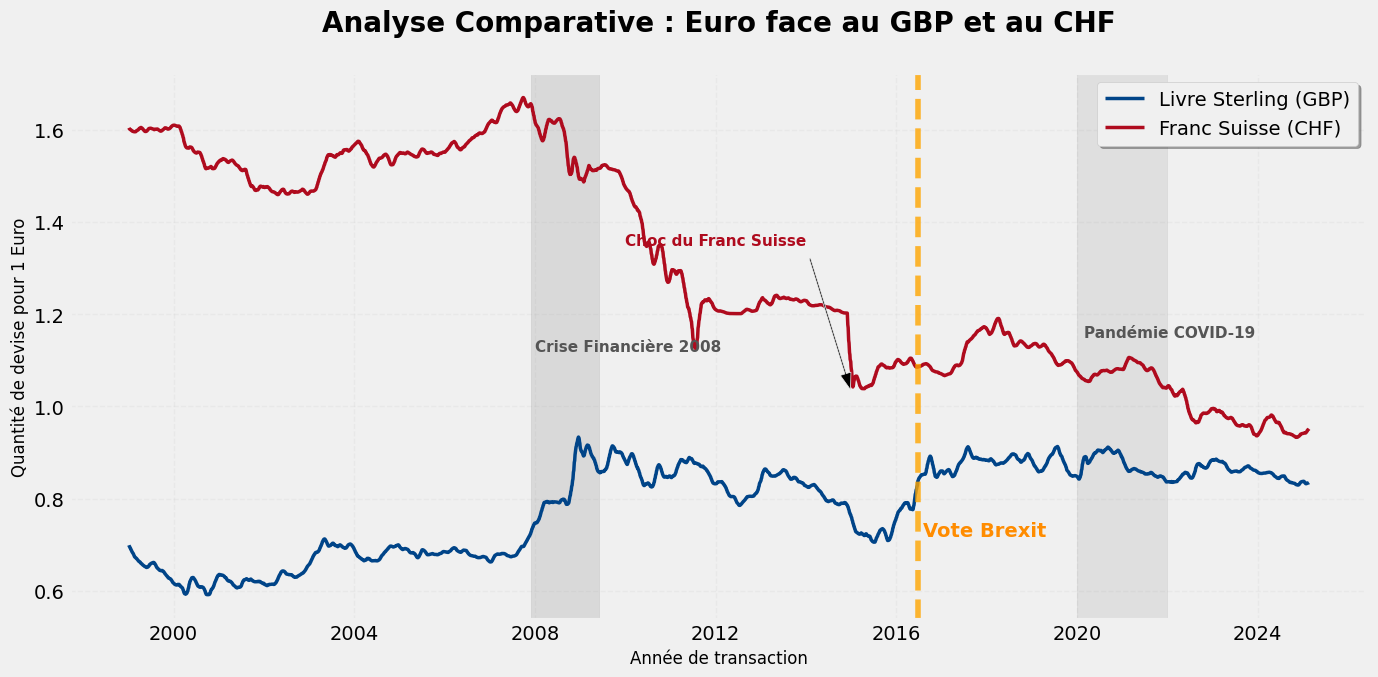

In [ ]:
import matplotlib.pyplot as plt

# Calcul des moyennes mobiles pour lisser les tendances (fenêtre de 30 jours)
euro_rate_df['rolling_mean_GBP'] = euro_rate_df['[UK pound sterling ]'].rolling(30).mean()
euro_rate_df['rolling_mean_CHF'] = euro_rate_df['[Swiss franc ]'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 7))

# Tracé des taux de change
ax.plot(euro_rate_df['Date'], euro_rate_df['rolling_mean_GBP'], label='Livre Sterling (GBP)', color='#004488', linewidth=2.5)
ax.plot(euro_rate_df['Date'], euro_rate_df['rolling_mean_CHF'], label='Franc Suisse (CHF)', color='#af0b1e', linewidth=2.5)

# --- AJOUT DU CONTEXTE HISTORIQUE ---

# 1. Crise financière mondiale (2007-2009)
ax.axvspan(pd.to_datetime('2007-12-01'), pd.to_datetime('2009-06-01'), alpha=0.2, color='grey')
ax.text(pd.to_datetime('2008-01-01'), 1.12, 'Crise Financière 2008', size=11, weight='bold', color='#555555')

# 2. Abandon du taux plancher par la BNS (Janvier 2015)
# AJUSTEMENT : On remonte la position Y du texte à 1.35 pour éviter le chevauchement avec la courbe GBP
ax.annotate('Choc du Franc Suisse',
             xy=(pd.to_datetime('2015-01-15'), 1.02),
             xytext=(pd.to_datetime('2010-01-01'), 1.35),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             color='#af0b1e', weight='bold', size=11)

# 3. Référendum sur le Brexit (Juin 2016)
ax.axvline(pd.to_datetime('2016-06-23'), color='orange', linestyle='--', alpha=0.8)
ax.text(pd.to_datetime('2016-08-01'), 0.72, 'Vote Brexit', color='darkorange', weight='bold')

# 4. Pandémie de COVID-19 (2020-2022)
ax.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2022-01-01'), alpha=0.15, color='grey')
ax.text(pd.to_datetime('2020-03-01'), 1.15, 'Pandémie COVID-19', size=11, weight='bold', color='#555555')

# Optimisation de l'affichage
ax.set_title('Analyse Comparative : Euro face au GBP et au CHF', size=20, weight='bold', pad=30)
ax.set_xlabel('Année de transaction', size=12)
ax.set_ylabel('Quantité de devise pour 1 Euro', size=12)
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.grid(visible=True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
### Narrative Analysis of Euro Exchange Rate Trends

The visualizations tell a compelling story of the Euro’s journey through two decades of global volatility. Initially, the charts reveal a period of relative strength for the Euro leading up to the **2008 Financial Crisis**, where it reached historic highs against the USD and GBP. This period represents the height of European economic optimism before the global shock forced a sharp correction.

#### Key Findings:
* **Political Impact (GBP):** The comparison with the **UK Pound Sterling** highlights the dramatic impact of political shifts, specifically the **2016 Brexit referendum**. The sudden, sustained spike in the EUR/GBP rate underscores the Pound's significant devaluation as uncertainty gripped the UK economy.
* **Safe Haven Dynamics (CHF):** The **Swiss Franc (CHF)** chart illustrates its role as a 'safe haven' currency. The most striking moment is the **2015 'CHF Shock'**, where the removal of the exchange rate floor by the Swiss National Bank caused an instantaneous surge in value.
* **Global Stress (COVID-19):** The **COVID-19 Pandemic** markers show a synchronized period of stress across all pairs. While the Euro faced downward pressure, the charts illustrate its eventual stabilization.

Together, these visualizations transform raw numbers into a historical map, showing how geopolitical events—from bank failures to referendums—directly reshape global purchasing power.

## Advanced Analysis: Currency Correlations

To add more depth to the project, let's examine how different currencies move in relation to one another. High correlation can indicate similar economic dependencies.

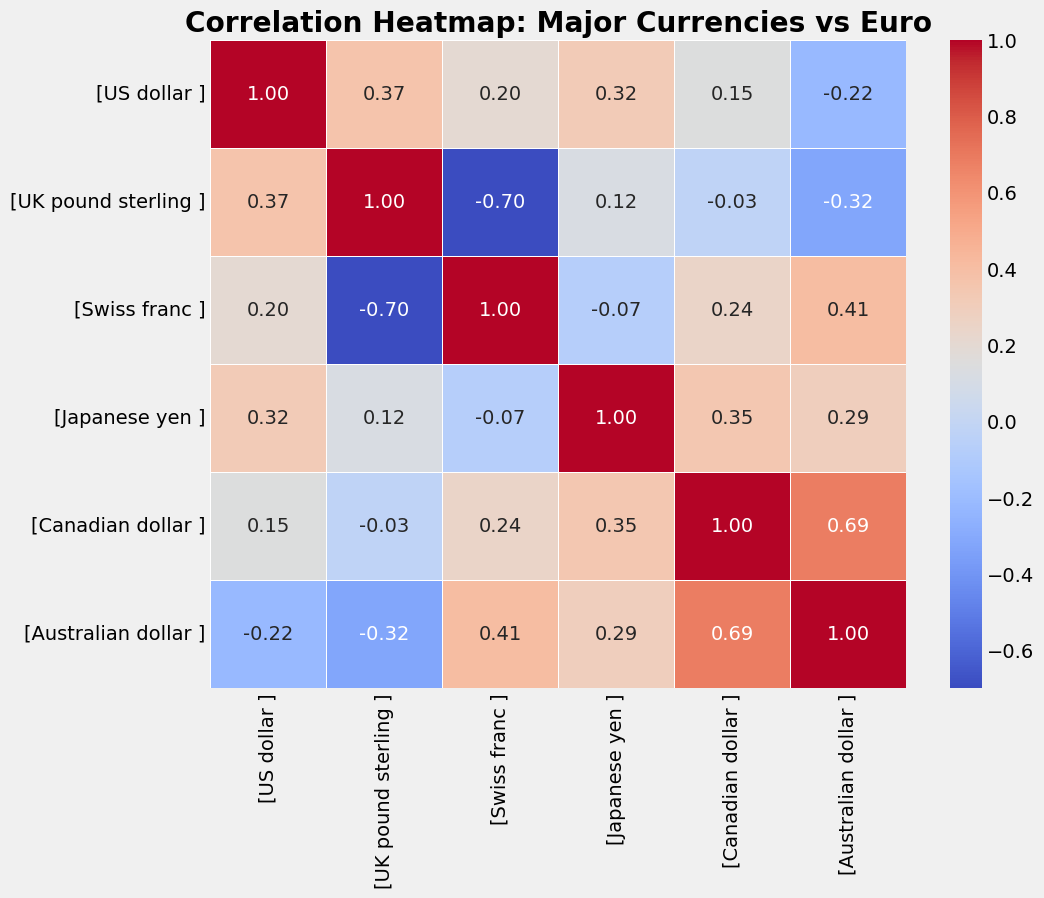

In [41]:
import seaborn as sns

# Selecting major currencies for correlation
major_currencies = ['[US dollar ]', '[UK pound sterling ]', '[Swiss franc ]', '[Japanese yen ]', '[Canadian dollar ]', '[Australian dollar ]']
corr_matrix = euro_rate_df[major_currencies].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Major Currencies vs Euro', weight='bold')
plt.show()

## Annual Performance Summary

Finally, we calculate the annual average exchange rates to identify the Euro's strongest and weakest years against the US Dollar.

In [42]:
euro_rate_df['Year'] = euro_rate_df['Date'].dt.year
annual_summary = euro_rate_df.groupby('Year')['[US dollar ]'].mean().reset_index()

# Highlighting extreme years
strongest_year = annual_summary.loc[annual_summary['[US dollar ]'].idxmax()]
weakest_year = annual_summary.loc[annual_summary['[US dollar ]'].idxmin()]

print(f"The Euro was strongest in {int(strongest_year['Year'])} (Avg: {strongest_year['[US dollar ]']:.2f} USD)")
print(f"The Euro was weakest in {int(weakest_year['Year'])} (Avg: {weakest_year['[US dollar ]']:.2f} USD)")

display(annual_summary.tail(10))

The Euro was strongest in 2008 (Avg: 1.47 USD)
The Euro was weakest in 2001 (Avg: 0.90 USD)


,Year,[US dollar ]
17,2016,1.106903
18,2017,1.129681
19,2018,1.180955
20,2019,1.119475
21,2020,1.142196
22,2021,1.182740
23,2022,1.053049
24,2023,1.081269
25,2024,1.082380
26,2025,1.053178
